# Tarea entrega final: Fine-tunning Stable Difusion

## 1. Datos generales de la tarea
- De acuerdo al documento PDF, he hecho las siguientes implementaciones acciones:
    - Crear un perfil en huggingFace (https://huggingface.co/Emmy1993)  
    - Exponer ahí mis dos modelos finetuneados (Más adelante explicaré porque tengo dos en vez de uno):
       - finetuned-sd-1.4-oldbookillustrations-entrega-runpod-io https://huggingface.co/Emmy1993/finetuned-sd-1.4-oldbookillustrations-entrega-runpod-io
       - finetuned-sd-1.4-oldbookillustrations-entrega https://huggingface.co/Emmy1993/finetuned-sd-1.4-oldbookillustrations-entrega ( **Defectuoso**)
- He creado dos archivos `.py` para cada finetuneado.
- Finalmente he completado todo el proceso (similar a como lo hicimos en clase).

In [53]:
from huggingface_hub import login
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTokenizer
import torch
from PIL import Image

In [54]:
# device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device = "cpu"
print(device)

pretrained_model_name = "CompVis/stable-diffusion-v1-4"
local_finetuned_dir = "./finetuned-model-oldbooks"

# El modelo se entreno viendo imagenes de 64x64 (limitacion de RAM en CPU), asi que
# generamos a esa misma resolucion para que la comparacion antes/despues sea coherente:
resolution = 512

# Mismo prompt para la imagen "antes" y la imagen "despues":
prompt = "Rome the best empire"

cpu


## 1. Imagen con el modelo base (antes del finetuning)

100%|██████████| 50/50 [01:49<00:00,  2.20s/it]


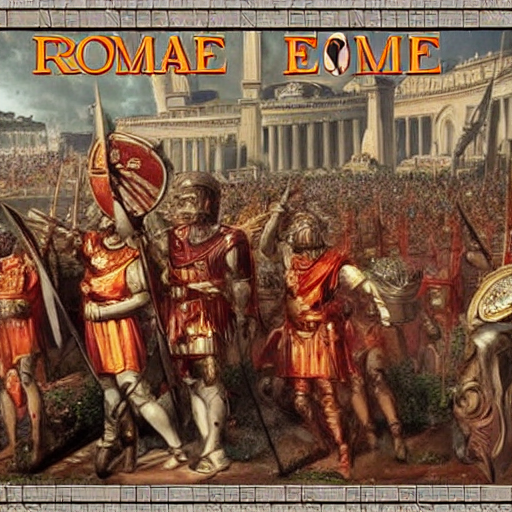

In [48]:
base_pipe = StableDiffusionPipeline.from_pretrained(pretrained_model_name).to(device)

image_antes = base_pipe(prompt, height=resolution, width=resolution).images[0]
image_antes.save("antes_finetuning.png")

del base_pipe
image_antes

## 2. Subir el modelo finetuneado a Hugging Face Hub


In [49]:
login()


In [50]:
# TODO: sustituye por tu usuario y el nombre de repo que quieras (se crea automaticamente si no existe):
repo_id = "Emmy1993/finetuned-sd-1.4-oldbookillustrations-entrega-runpod-io"

finetuned_unet = UNet2DConditionModel.from_pretrained(local_finetuned_dir)
finetuned_tokenizer = CLIPTokenizer.from_pretrained(local_finetuned_dir)

finetuned_unet.push_to_hub(repo_id)
finetuned_tokenizer.push_to_hub(repo_id)

print(f"Modelo subido a https://huggingface.co/{repo_id}")

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Modelo subido a https://huggingface.co/Emmy1993/finetuned-sd-1.4-oldbookillustrations-entrega-runpod-io


## 3. Cargar el modelo finetuneado desde Hugging Face y generar una imagen

100%|██████████| 50/50 [01:48<00:00,  2.18s/it]


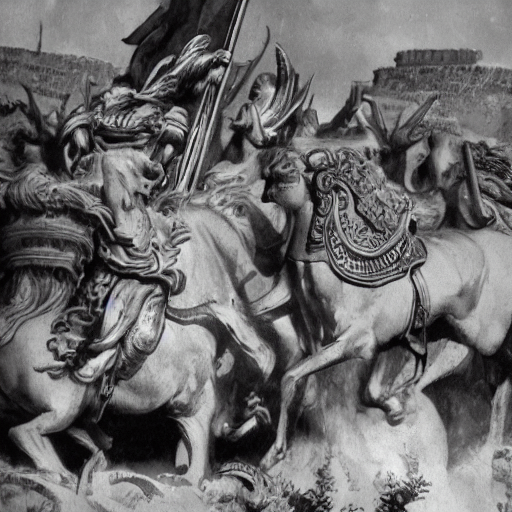

In [51]:
finetuned_unet_from_hub = UNet2DConditionModel.from_pretrained(repo_id).to(device)

pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name,
    unet=finetuned_unet_from_hub,
).to(device)

image_despues = pipe(prompt, height=resolution, width=resolution).images[0]
image_despues.save("despues_finetuning.png")
image_despues

## 4. Comparacion antes / despues

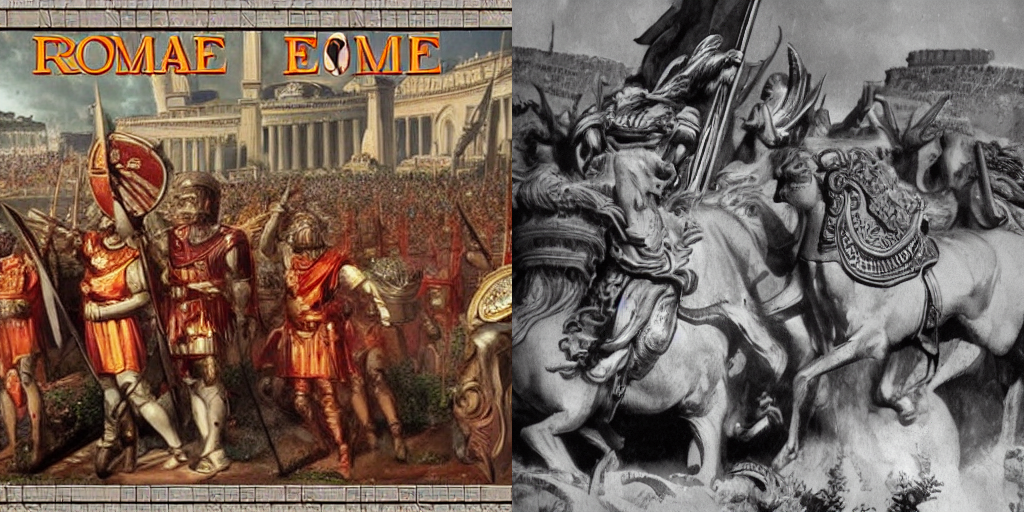

In [52]:
def combinar_lado_a_lado(img1, img2):
    width = img1.width + img2.width
    height = max(img1.height, img2.height)
    combinada = Image.new("RGB", (width, height), color="white")
    combinada.paste(img1, (0, 0))
    combinada.paste(img2, (img1.width, 0))
    return combinada


comparacion = combinar_lado_a_lado(image_antes, image_despues)
comparacion.save("comparacion_antes_despues.png")
comparacion